# Import libraries

In [1]:
# Changes to all modules will automatically be applied when any cell runs. 
%load_ext autoreload
%autoreload 2

In [8]:
import pandas as pd
import numpy as np

import optuna

from pathlib import Path
import sys

from typing import Type
from sklearn.base import BaseEstimator
sys.path.append(
    str(Path('..', 'utils_functionality', 'split_utils'))
)
from split_tools import get_train_test

sys.path.append(
    str(Path('..', 'utils_functionality', 'models'))
)

from modelling4_utils import (
    BetaVAEncoder,
    MLPipeline,
    OptunaOptimizer,
    deep_update,
    deep_update_dim_transformer_params,
    RANDOM_STATE,
)

seed = RANDOM_STATE

from catboost import CatBoostClassifier
from statsmodels.api import Logit

from sklearn.decomposition import PCA

from sklearn.metrics import (
    make_scorer,
    f1_score,
    mean_squared_error
)

import optuna
from functools import partial

from copy import deepcopy

## Settings

In [3]:
model_postfix = 'vae'

scoring_metrics={
    'mse': mean_squared_error,
}
step_scoring_average = "mean"
n_trials = 1000 # make 300

features_to_drop=(
    'sign_sedimentation_Re',
    'sign_sedimentation_Stk',
    'sign_particle_droplet_diameter_ratio',
)

save_model_and_metrics = False
metrics_file = "metrics_modelling4_7-dim_reduction.xlsx"

## Optimization function

In [4]:
def optimize_vae_optuna(
    dim_transformer:Type[BaseEstimator]=BetaVAEncoder,
    dim_transformer_params:dict=None,
    dummy_target:str='splashing', # placeholder
    dummy_estimator:Type[BaseEstimator]=CatBoostClassifier,  # placeholder
    objective:callable=None,
    direction:str="minimize",
    n_trials:int=n_trials,
    features_to_drop:tuple=features_to_drop,
    step_scoring_average:str=step_scoring_average,
    scoring_metrics:dict=scoring_metrics,
    verbose:bool=True,
    opt_cv_folds:int=5,
    seed:int=seed,
):
    dim_transformer_params = dim_transformer_params or {}
    
    ml_pipe = MLPipeline(
        target=dummy_target,
        estimator=dummy_estimator,
        dim_transformer=dim_transformer,
        dim_transformer_params=dim_transformer_params,
        features_to_drop=features_to_drop,
        cv_folds=opt_cv_folds,
        verbose=verbose,
        step_scoring_average=step_scoring_average,
        scoring_metrics=scoring_metrics,
    )
    
    opt = OptunaOptimizer(
        objective=partial(
            objective,
            ml_pipe=ml_pipe,
        ),
        study_name='VAE_study',
        direction=direction,
        seed=seed,
    )
    
    opt.optimize(n_trials=n_trials)
    
    best_params = opt.study.best_params
    
    print('raw best_params')
    display(best_params)


def VAE_objective(
    trial:optuna.trial.Trial,
    ml_pipe:MLPipeline,
):
    # VAE params
    hidden_dim = 2**trial.suggest_int('log2_hidden_dim', 2, 8)
    normalization = trial.suggest_categorical('normalization', ['batch', 'layer', False])
    activation = trial.suggest_categorical('activation', ['ReLU', 'LeakyReLU', False])
    
    if activation == 'LeakyReLU':
        negative_slope = trial.suggest_float('negative_slope', 0.01, .3, log=True)
    else:
        negative_slope = None
    
    # BetaVAEncoder params
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
    beta_warmup_steps = trial.suggest_int('beta_warmup_steps', 100, 1000)
    beta_start = trial.suggest_float('beta_start', 0.0, 0.5)
    beta_end = trial.suggest_float('beta_end', 1.0, 10.0)
    
    suggested_transformer_params = {
        'VAE_params': {
            'hidden_dim': hidden_dim,
            'normalization': normalization,
            'activation': activation,
            'negative_slope': negative_slope,
        },
        'learning_rate': learning_rate,
        'beta_warmup_steps': beta_warmup_steps,
        'beta_start': beta_start,
        'beta_end': beta_end,
    }
    
    dim_transformer_params = deep_update_dim_transformer_params(
        ml_pipe=ml_pipe,
        suggested_params=suggested_transformer_params,
    )
    
    score = ml_pipe.step_transformer(
        dim_transformer_params=dim_transformer_params,
    )
    
    score_val = score[0]
    # score_train = score[1]
    return score_val


In [5]:
dim_transformer_params = {
    'VAE_params': {
            'latent_dim': 5,
        },
    'verbose': False,
    'early_stopping': True,
    'early_stopping_patience': 30,
    'max_epochs': 300,
}

optimize_vae_optuna(
    dim_transformer_params=dim_transformer_params,
    objective=VAE_objective,
)

Load dataset from: ../data/df_dimless.xlsx
Keep "splashing" from {'splashing', 'no_fragmentation'}
Load split indexes from: ../data/df_ml_split_splashing.xlsx
std_features


('sedimentation_Re',
 'sedimentation_Stk',
 'particle_liquid_density_ratio',
 'particle_droplet_diameter_ratio',
 'relative_roughness',
 'Re',
 'We',
 'K')

ColumnTransformer(transformers=[('minmax', MinMaxScaler(),
                                 ('inclination', 'init_volume_fraction',
                                  'volume_fraction')),
                                ('std', StandardScaler(),
                                 ('sedimentation_Re', 'sedimentation_Stk',
                                  'particle_liquid_density_ratio',
                                  'particle_droplet_diameter_ratio',
                                  'relative_roughness', 'Re', 'We', 'K')),
                                ('passthrough', 'passthrough',
                                 ('wettability',))])

[I 2025-05-02 13:49:49,321] A new study created in memory with name: VAE_study
[I 2025-05-02 13:49:50,770] Trial 0 finished with value: 0.28220390260717537 and parameters: {'log2_hidden_dim': 4, 'normalization': 'batch', 'activation': 'ReLU', 'learning_rate': 0.029154431891537533, 'beta_warmup_steps': 641, 'beta_start': 0.35403628889802274, 'beta_end': 1.185260448662222}. Best is trial 0 with value: 0.28220390260717537.
[I 2025-05-02 13:49:51,819] Trial 1 finished with value: 0.4055141708444112 and parameters: {'log2_hidden_dim': 8, 'normalization': 'batch', 'activation': False, 'learning_rate': 0.0005342937261279777, 'beta_warmup_steps': 362, 'beta_start': 0.30592644736118974, 'beta_end': 2.2554447458683766}. Best is trial 0 with value: 0.28220390260717537.
[I 2025-05-02 13:49:52,717] Trial 2 finished with value: 0.8228577549480847 and parameters: {'log2_hidden_dim': 4, 'normalization': False, 'activation': False, 'learning_rate': 1.5339162591163613e-05, 'beta_warmup_steps': 647, 'bet

raw best_params


{'log2_hidden_dim': 7,
 'normalization': False,
 'activation': 'LeakyReLU',
 'negative_slope': 0.07725532864528295,
 'learning_rate': 0.02614154303904056,
 'beta_warmup_steps': 984,
 'beta_start': 0.0006117233010319704,
 'beta_end': 1.003540955367511}

In [15]:
dim_transformer_params = {
    'VAE_params': {
            'latent_dim': 5,
        },
    'verbose': False,
    'early_stopping': True,
    'early_stopping_patience': 30,
    'max_epochs': 300,
}

In [17]:
def get_vae_params(
    raw_vae_params:dict,
):
    hidden_dim = 2**raw_vae_params['log2_hidden_dim']
    suggested_transformer_params = {
        'VAE_params': {
            'hidden_dim': hidden_dim,
            'normalization': raw_vae_params['normalization'],
            'activation': raw_vae_params['activation'],
            'negative_slope': raw_vae_params['negative_slope'],
        },
        'learning_rate':    raw_vae_params['learning_rate'],
        'beta_warmup_steps': raw_vae_params['beta_warmup_steps'],
        'beta_start':       raw_vae_params['beta_start'],
        'beta_end':         raw_vae_params['beta_end'],
    }
    
    return suggested_transformer_params
    
raw_vae_params = {
    'log2_hidden_dim': 7,
    'normalization': False,
    'activation': 'LeakyReLU',
    'negative_slope': 0.07725532864528295,
    'learning_rate': 0.02614154303904056,
    'beta_warmup_steps': 984,
    'beta_start': 0.0006117233010319704,
    'beta_end': 1.003540955367511,
}

suggested_transformer_params = get_vae_params(
    raw_vae_params=raw_vae_params
)

dim_transformer_params = deepcopy(dim_transformer_params)

deep_update(
    original=dim_transformer_params,
    updates=suggested_transformer_params,
)
dim_transformer_params['verbose'] = True
display(dim_transformer_params)

{'VAE_params': {'latent_dim': 5,
  'hidden_dim': 128,
  'normalization': False,
  'activation': 'LeakyReLU',
  'negative_slope': 0.07725532864528295},
 'verbose': True,
 'early_stopping': True,
 'early_stopping_patience': 30,
 'max_epochs': 300,
 'learning_rate': 0.02614154303904056,
 'beta_warmup_steps': 984,
 'beta_start': 0.0006117233010319704,
 'beta_end': 1.003540955367511}

Load dataset from: ../data/df_dimless.xlsx
Keep "splashing" from {'splashing', 'no_fragmentation'}
Load split indexes from: ../data/df_ml_split_splashing.xlsx
std_features


('sedimentation_Re',
 'sedimentation_Stk',
 'particle_liquid_density_ratio',
 'particle_droplet_diameter_ratio',
 'relative_roughness',
 'Re',
 'We',
 'K')

ColumnTransformer(transformers=[('minmax', MinMaxScaler(),
                                 ('inclination', 'init_volume_fraction',
                                  'volume_fraction')),
                                ('std', StandardScaler(),
                                 ('sedimentation_Re', 'sedimentation_Stk',
                                  'particle_liquid_density_ratio',
                                  'particle_droplet_diameter_ratio',
                                  'relative_roughness', 'Re', 'We', 'K')),
                                ('passthrough', 'passthrough',
                                 ('wettability',))])

[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.8s
VAE_params: {'latent_dim': 5, 'hidden_dim': 128, 'normalization': False, 'activation': 'LeakyReLU', 'negative_slope': 0.07725532864528295, 'input_dim': 12, 'verbose': True}
Encoder: Sequential(
  (0): Linear(in_features=12, out_features=128, bias=True)
  (1): LeakyReLU(negative_slope=0.07725532864528295, inplace=True)
)
Latent space:
	Mu: Linear(in_features=128, out_features=5, bias=True)
	log_sigma2: Linear(in_features=128, out_

Epochs:   0%|          | 0/300 [00:00<?, ?it/s]

Early stopping at epoch 33.
no summary in estimator class "CatBoostClassifier"


,0
target,splashing
model,CatBoostClassifier_splashing_smote_vae
holdout_test_f1_macro,0.816072
holdout_test_accuracy_balanced,0.824074
holdout_test_roc_auc,0.894676
holdout_test_f1,0.860215
holdout_test_accuracy,0.826667
cv_test_f1_macro_median,0.842262
cv_test_accuracy_balanced_median,0.859133
cv_test_roc_auc_median,0.911765


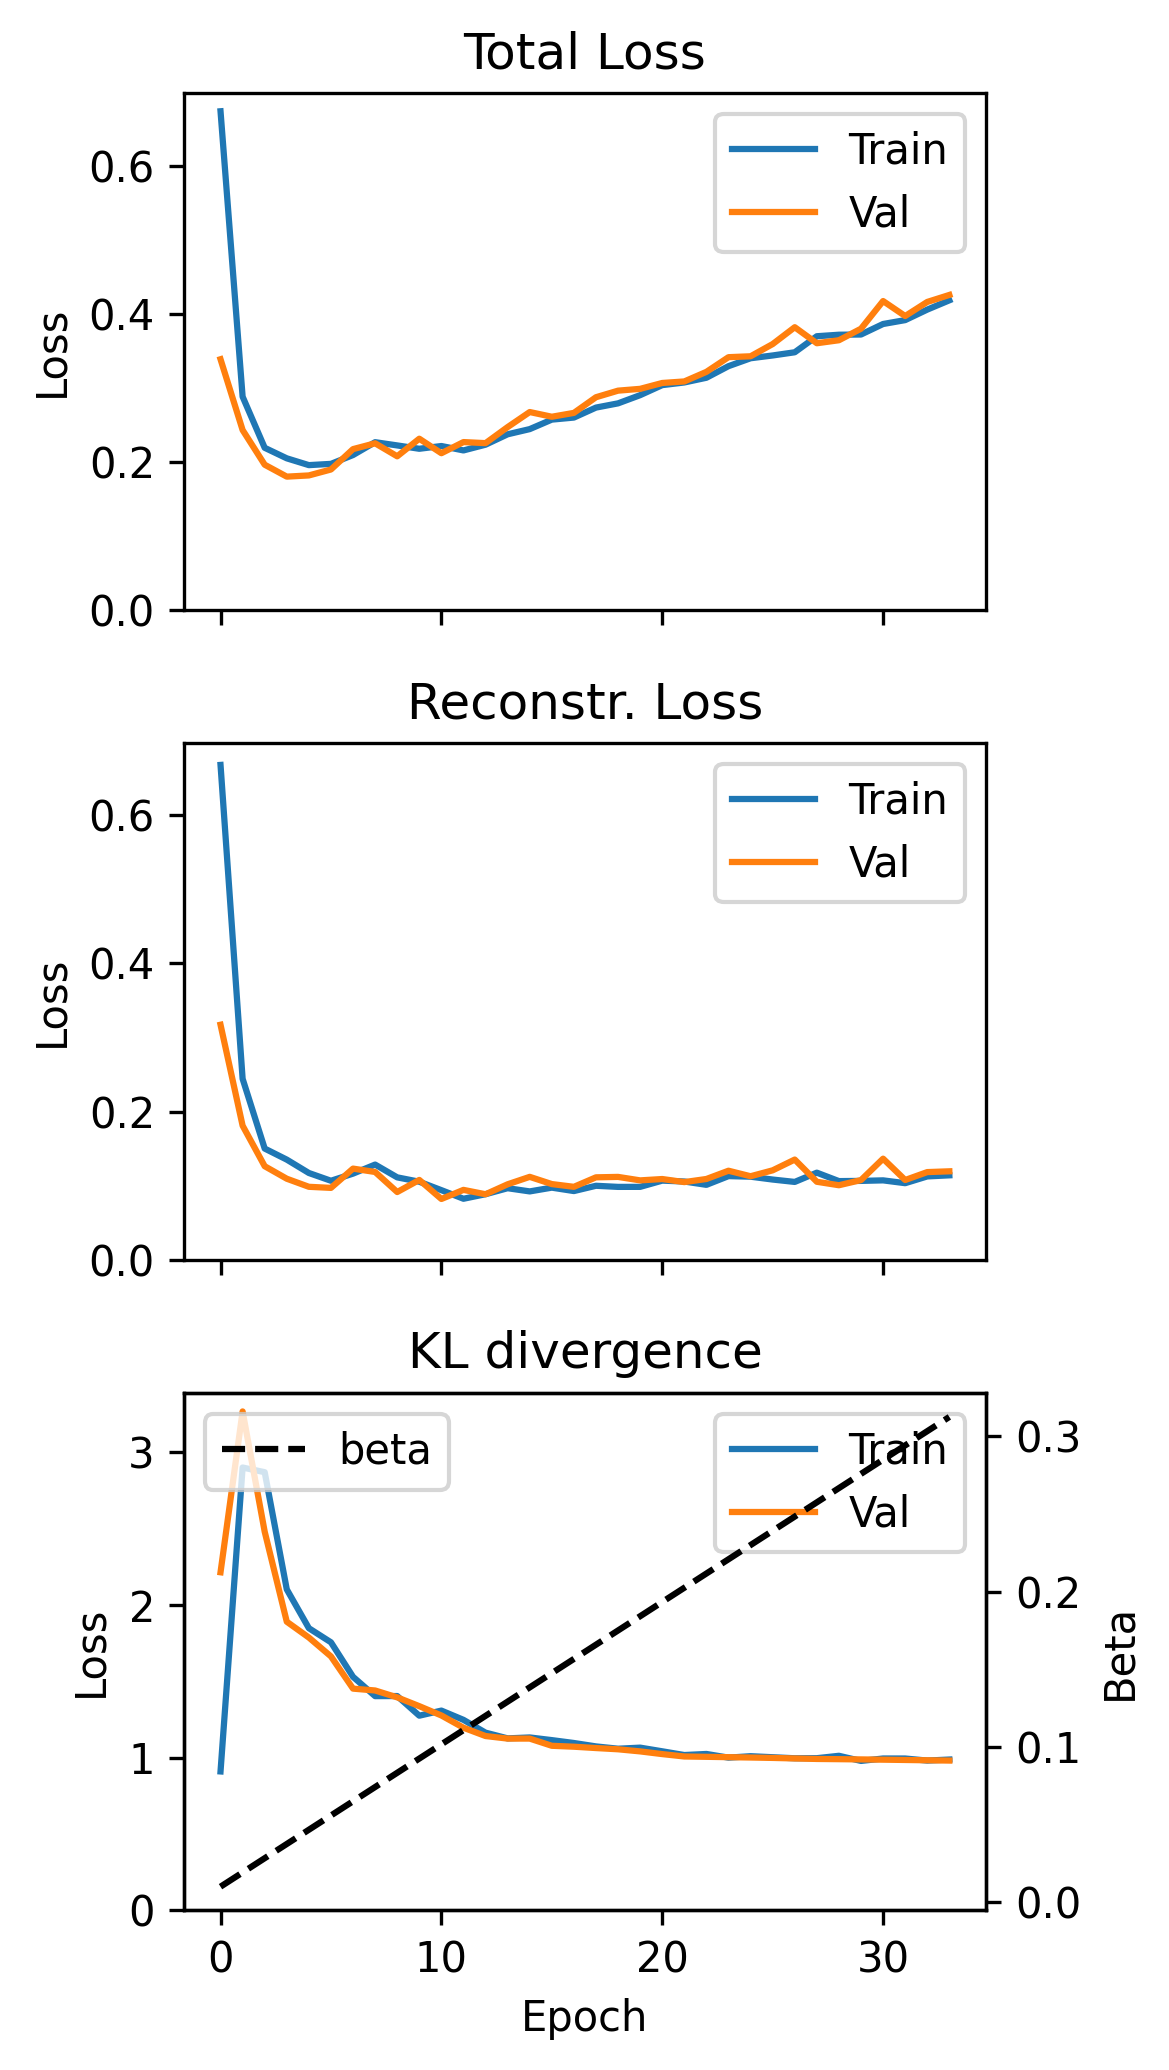

In [19]:

# To simplify data extraction, initialize ml_pipe
target = 'splashing'

ml_pipe = MLPipeline(
    target=target,
    estimator=CatBoostClassifier,
    estimator_params={'verbose': False,},
    # dim_transformer=PCA,
    # dim_transformer_params={'n_components': 6},
    dim_transformer=BetaVAEncoder,
    dim_transformer_params=dim_transformer_params,
    features_to_drop=features_to_drop,
    model_postfix=model_postfix,
    verbose=True,
)

# X_train = ml_pipe.train.drop(columns=[target])
# X_test = ml_pipe.test.drop(columns=[target])
# display(X_train.info())
# display(X_test.info())

ml_pipe.run(
    save_model_and_metrics=False,
    cv_verbose=False,
)

In [22]:

# To simplify data extraction, initialize ml_pipe
target = 'splashing'

ml_pipe = MLPipeline(
    target=target,
    estimator=CatBoostClassifier,
    estimator_params={'verbose': False,},
    model_postfix='default',
    verbose=True,
)

# X_train = ml_pipe.train.drop(columns=[target])
# X_test = ml_pipe.test.drop(columns=[target])
# display(X_train.info())
# display(X_test.info())

ml_pipe.run(
    save_model_and_metrics=False,
    cv_verbose=False,
)

Load dataset from: ../data/df_dimless.xlsx
Keep "splashing" from {'splashing', 'no_fragmentation'}
Load split indexes from: ../data/df_ml_split_splashing.xlsx
std_features


('sedimentation_Stk',
 'particle_droplet_diameter_ratio',
 'relative_roughness',
 'K')

ColumnTransformer(transformers=[('minmax', MinMaxScaler(),
                                 ('inclination', 'volume_fraction')),
                                ('std', StandardScaler(),
                                 ('sedimentation_Stk',
                                  'particle_droplet_diameter_ratio',
                                  'relative_roughness', 'K')),
                                ('passthrough', 'passthrough',
                                 ('wettability',))])

[CV] END .................................................... total time=   0.6s
[CV] END .................................................... total time=   0.6s
[CV] END .................................................... total time=   0.6s
[CV] END .................................................... total time=   0.6s
[CV] END .................................................... total time=   0.6s
[CV] END .................................................... total time=   0.7s
[CV] END .................................................... total time=   0.6s
no summary in estimator class "CatBoostClassifier"


,0
target,splashing
model,CatBoostClassifier_splashing_smote_default
holdout_test_f1_macro,0.882261
holdout_test_accuracy_balanced,0.876157
holdout_test_roc_auc,0.952932
holdout_test_f1,0.918367
holdout_test_accuracy,0.893333
cv_test_f1_macro_median,0.881696
cv_test_accuracy_balanced_median,0.900155
cv_test_roc_auc_median,0.950464


### PCA

In [24]:

# To simplify data extraction, initialize ml_pipe
target = 'splashing'

ml_pipe = MLPipeline(
    target=target,
    estimator=CatBoostClassifier,
    estimator_params={'verbose': False,},
    dim_transformer=PCA,
    dim_transformer_params={'n_components': 5},
    features_to_drop=features_to_drop,
    model_postfix=model_postfix,
    verbose=True,
)

ml_pipe.run(
    save_model_and_metrics=False,
    cv_verbose=False,
)

Load dataset from: ../data/df_dimless.xlsx
Keep "splashing" from {'splashing', 'no_fragmentation'}
Load split indexes from: ../data/df_ml_split_splashing.xlsx
std_features


('sedimentation_Re',
 'sedimentation_Stk',
 'particle_liquid_density_ratio',
 'particle_droplet_diameter_ratio',
 'relative_roughness',
 'Re',
 'We',
 'K')

ColumnTransformer(transformers=[('minmax', MinMaxScaler(),
                                 ('inclination', 'init_volume_fraction',
                                  'volume_fraction')),
                                ('std', StandardScaler(),
                                 ('sedimentation_Re', 'sedimentation_Stk',
                                  'particle_liquid_density_ratio',
                                  'particle_droplet_diameter_ratio',
                                  'relative_roughness', 'Re', 'We', 'K')),
                                ('passthrough', 'passthrough',
                                 ('wettability',))])

[CV] END .................................................... total time=   0.7s
[CV] END .................................................... total time=   0.7s
[CV] END .................................................... total time=   0.7s
[CV] END .................................................... total time=   0.7s
[CV] END .................................................... total time=   0.7s
[CV] END .................................................... total time=   0.7s
[CV] END .................................................... total time=   0.7s
no summary in estimator class "CatBoostClassifier"


,0
target,splashing
model,CatBoostClassifier_splashing_smote_vae
holdout_test_f1_macro,0.818402
holdout_test_accuracy_balanced,0.832176
holdout_test_roc_auc,0.931327
holdout_test_f1,0.857143
holdout_test_accuracy,0.826667
cv_test_f1_macro_median,0.858018
cv_test_accuracy_balanced_median,0.862229
cv_test_roc_auc_median,0.938095


In [25]:

# To simplify data extraction, initialize ml_pipe
target = 'splashing'

ml_pipe = MLPipeline(
    target=target,
    estimator=CatBoostClassifier,
    estimator_params={'verbose': False,},
    dim_transformer=PCA,
    dim_transformer_params={'n_components': 7},
    features_to_drop=features_to_drop,
    model_postfix=model_postfix,
    verbose=True,
)

ml_pipe.run(
    save_model_and_metrics=False,
    cv_verbose=False,
)

Load dataset from: ../data/df_dimless.xlsx
Keep "splashing" from {'splashing', 'no_fragmentation'}
Load split indexes from: ../data/df_ml_split_splashing.xlsx
std_features


('sedimentation_Re',
 'sedimentation_Stk',
 'particle_liquid_density_ratio',
 'particle_droplet_diameter_ratio',
 'relative_roughness',
 'Re',
 'We',
 'K')

ColumnTransformer(transformers=[('minmax', MinMaxScaler(),
                                 ('inclination', 'init_volume_fraction',
                                  'volume_fraction')),
                                ('std', StandardScaler(),
                                 ('sedimentation_Re', 'sedimentation_Stk',
                                  'particle_liquid_density_ratio',
                                  'particle_droplet_diameter_ratio',
                                  'relative_roughness', 'Re', 'We', 'K')),
                                ('passthrough', 'passthrough',
                                 ('wettability',))])

[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.7s
[CV] END .................................................... total time=   0.7s
[CV] END .................................................... total time=   0.7s
[CV] END .................................................... total time=   0.7s
no summary in estimator class "CatBoostClassifier"


,0
target,splashing
model,CatBoostClassifier_splashing_smote_vae
holdout_test_f1_macro,0.84634
holdout_test_accuracy_balanced,0.861111
holdout_test_roc_auc,0.935957
holdout_test_f1,0.879121
holdout_test_accuracy,0.853333
cv_test_f1_macro_median,0.881696
cv_test_accuracy_balanced_median,0.891641
cv_test_roc_auc_median,0.946032
